# **Extended Summary

This study investigates the generalization behavior of value-based reinforcement learning (RL) agents for cloud autoscaling under diverse workload regimes. Modern cloud environments exhibit substantial non-stationarity—ranging from smooth predictable load patterns to abrupt and bursty demand spikes—yet RL-based autoscaling methods are typically trained and evaluated in a single environment. To address this gap, we perform a systematic cross-environment generalization analysis in which agents are trained only once and evaluated across multiple workload distributions without retraining.

---

## **Training Environment**

We constructed a smoothed autoscaling environment derived from Google Cloud CPU utilization traces. This “Smooth” environment reduces short-term variance while preserving the long-term dynamics of cloud workloads, enabling stable training for value-based agents. Using this environment exclusively, we trained three RL agents:

- **DQN**  
- **Double DQN**  
- **Dueling Double DQN**

All agents share the same state and action spaces; their only differences lie in value-estimation architecture.

---

## **Evaluation Environments**

To test zero-shot generalization, we designed two additional environments using distinct CPU demand patterns:

1. **Seasonal** — periodic and oscillatory load patterns  
2. **Bursty** — high-volatility load with abrupt spikes  
3. **Smooth** — training environment (in-distribution baseline)

Agents were **not retrained** on Seasonal or Bursty. This allows for a controlled assessment of architectural robustness to distribution shift.

---

## **Evaluation Procedure**

For each of the nine (environment × agent) combinations, we generated complete control trajectories and collected:

- CPU demand  
- chosen capacity  
- utilization  
- rewards  
- SLA violations  

The key performance metric is the **mean episodic reward**, where higher values indicate better autoscaling performance (less cost, fewer SLA violations).

---

## **Results**

The aggregated results are shown below (higher is better):

| **Environment** | **DQN** | **DoubleDQN** | **DuelingDoubleDQN** |
|------------------|-----------|-----------------|------------------------|
| **Seasonal** | -3743.63 | -3617.40 | **-2958.07** |
| **Smooth** | -4297.70 | -3572.34 | **-2946.43** |
| **Bursty** | **-15214.43** | -17600.77 | -25356.05 |

Two important patterns emerge:

---

## **1. Dueling Double DQN excels in Smooth and Seasonal environments**

Dueling architectures decompose the Q-function into a state-value component and an advantage component:

\[
Q(s,a) = V(s) + A(s,a)
\]

This structure improves learning when the environment contains **predictable or periodic structure**, as is the case for the Smooth and Seasonal workloads.  
The dueling network:

- stabilizes value prediction,  
- differentiates meaningful action advantages,  
- and reduces variance from noisy transitions.

This leads to:

- **Best performance in Smooth** (in-distribution)  
- **Best performance in Seasonal** (moderately shifted)

Double DQN also improves over DQN in these environments, reflecting reduced overestimation bias.

---

## **2. Under extreme volatility (Bursty), DQN generalizes best**

The Bursty workload is characterized by:

- abrupt demand spikes,  
- highly non-stationary transitions,  
- and large reward discontinuities.  

In such environments, value decomposition—a key feature of dueling networks—**fails to capture the true volatility**, causing:

- miscalibrated value estimates,  
- erratic advantage predictions,  
- and delayed reactions to spikes.

Double DQN also suffers from reduced responsiveness due to its bias correction.

In contrast, **the simpler DQN architecture makes fewer structural assumptions** and reacts **more directly** to recent transitions. This allows it to adapt more quickly to sudden changes in workload, even though it is theoretically less sophisticated.

Thus:

- **DQN achieves the best performance on Bursty**,  
- while Dueling Double DQN performs the worst by a wide margin.

This inversion is consistent with RL literature: under highly noisy, adversarial, or rapidly changing dynamics, simpler value estimators often outperform more structured ones because they lack brittle inductive biases.

---

## **Implications**

These results highlight that:

- **Model architecture interacts strongly with workload structure.**  
  No single agent performs best across all workload types.

- **Training on smooth data does not ensure robustness in volatile environments.**  
  Autoscaling systems intended for production should be evaluated against a broad set of workload regimes, including worst-case burstiness.

- **Architecture matters most when the workload has exploitable structure.**  
  Dueling Double DQN thrives when the environment is smooth or periodic, but struggles when value estimation requires rapid adaptation.

- **Simplicity can enhance robustness under extreme distribution shift.**

---

## **Conclusion**

This work provides a clear demonstration that RL autoscaling agents trained in a single environment exhibit dramatically different generalization performance depending on workload volatility. Smooth and seasonal patterns favor architectures with decomposed value functions, while chaotic, spiky workloads favor simpler, reactive estimators. Production-ready RL autoscaling systems must therefore be evaluated across diverse workload distributions and may benefit from hybrid or adaptive approaches that select architectures based on detected workload characteristics.


#Download Files from Repo

In [ ]:
import os


GITHUB_USER = "rah-ds"
REPO_NAME   = "Cloud-Autoscaling-using-RL"
BRANCH      = "bmcgregor/simulator-refactor"  # or "main" or another branch

# Base raw URL for GitHub
BASE_RAW_URL = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}"

# Map of local filename -> path inside the repo

PY_FILES = {
    # Environment
    "autoscaling_env.py": "scripts/autoscaling_env.py",

    # DQN utilities and agents
    "DQN_Utils.py": "scripts/DQN_Utils.py",
    "DQN_Agent.py": "scripts/DQN_Agent.py",
    "Double_DQN_Agent.py": "scripts/Double_DQN_Agent.py",

}

print("Downloading Python files from GitHub...")
# Use a cross-platform Python downloader: try requests, fall back to urllib
try:
    import requests  # type: ignore
except Exception:
    requests = None

from urllib.request import urlopen, Request


# Directly set the download directory to /content/
DOWNLOAD_DIR = "/content/"
os.makedirs(DOWNLOAD_DIR, exist_ok=True) # Ensure the directory exists
print("Writing downloads to:", DOWNLOAD_DIR)

for local_name, repo_path in PY_FILES.items():
    url = f"{BASE_RAW_URL}/{repo_path}"
    print(f"  -> {local_name}  from  {url}")
    content = None
    if requests is not None:
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            content = resp.content
        except Exception as e:
            print(f"requests download failed: {e}; falling back to urllib")
            content = None
    if content is None:
        req = Request(url, headers={"User-Agent": "python-urllib/3"})
        try:
            with urlopen(req, timeout=30) as r:
                content = r.read()
        except Exception as e:
            print(f"Failed to download {url}: {e}")
            continue
    target_path = os.path.join(DOWNLOAD_DIR, local_name)
    try:
        with open(target_path, "wb") as f:
            f.write(content)
    except Exception as e:
        print(f"Failed to write {target_path}: {e}")

print("Done. Files in download dir:", os.listdir(DOWNLOAD_DIR))

Writing downloads to: /content/
  -> autoscaling_env.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
  -> DQN_Utils.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
  -> DQN_Agent.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/DQN_Agent.py
  -> Double_DQN_Agent.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Done. Files in download dir: ['.config', 'autoscaling_env.py', 'DQN_Utils.py', 'Double_DQN_Agent.py', 'DQN_Agent.py', '__pycache__', 'drive', 'sample_data']


#Setup: Imports and mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# modules
from DQN_Agent import DQNAgent
from Double_DQN_Agent import DoubleDQNAgent
from DQN_Utils import evaluate_agent

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


#Load the trained models

In [ ]:
# Folder in your Google Drive where you saved the model weights
MODEL_DIR = "/content/drive/MyDrive/RL_Checkpoints/"

DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "dqn_checkpoint.pth")
DOUBLE_DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "double_dqn_checkpoint.pth")
DUELING_DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "dueling_dqn_checkpoint.pth")

for p in [DQN_CHECKPOINT_PATH, DOUBLE_DQN_CHECKPOINT_PATH, DUELING_DQN_CHECKPOINT_PATH]:
    print(p, "exists?", os.path.exists(p))


/content/drive/MyDrive/RL_Checkpoints/dqn_checkpoint.pth exists? True
/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth exists? True
/content/drive/MyDrive/RL_Checkpoints/dueling_dqn_checkpoint.pth exists? True


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load df_usage
df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')

#1. Environment A – “Smooth Real” (Baseline from Google Data)

In [ ]:
from autoscaling_env import AutoScalingEnvConfig, AutoScalingEnv
from copy import deepcopy

df_smooth = df_usage.copy()

config_smooth = AutoScalingEnvConfig(
    initial_capacity=10,
    target_utilization=0.6,
    sla_threshold=0.8,
    cost_per_machine_per_minute=0.002,
    min_capacity=1,
    max_capacity=20,
    cooldown_period=5,
    demand_scale=1000.0,
    cost_weight=1.0,
    util_weight=1.0,
    sla_weight=10.0,
)

env_smooth = AutoScalingEnv(df_smooth, config=config_smooth)


# Environment B – “Bursty” (Inject Spikes into the Google Trace)

In [ ]:
def make_bursty_df(df,
                   spike_prob=0.02,         # ~2% of time steps start a spike
                   spike_length_range=(5, 20),
                   spike_mult_range=(3.0, 7.0),
                   random_state=0):
    rng = np.random.RandomState(random_state)
    df_bursty = df.copy()
    n = len(df_bursty)

    # Start with original avg_cpu
    cpu = df_bursty["avg_cpu"].values.copy()

    i = 0
    while i < n:
        if rng.rand() < spike_prob:
            # create a spike interval
            spike_len = rng.randint(spike_length_range[0], spike_length_range[1] + 1)
            spike_mult = rng.uniform(spike_mult_range[0], spike_mult_range[1])
            j_end = min(i + spike_len, n)
            cpu[i:j_end] = cpu[i:j_end] * spike_mult
            i = j_end
        else:
            i += 1

    # Optional: cap CPU at some reasonable max (e.g., 1.0)
    cpu = np.clip(cpu, 0.0, 1.0)
    df_bursty["avg_cpu"] = cpu
    return df_bursty

df_bursty = make_bursty_df(df_usage)


In [ ]:
config_bursty = AutoScalingEnvConfig(
    initial_capacity=10,
    target_utilization=0.6,
    sla_threshold=0.8,
    cost_per_machine_per_minute=0.002,
    min_capacity=1,
    max_capacity=20,
    cooldown_period=2,      # shorter cooldown so agent can react more
    demand_scale=1000.0,
    cost_weight=1.0,
    util_weight=1.0,
    sla_weight=15.0,        # SLA a bit more important under bursts
)

env_bursty = AutoScalingEnv(df_bursty, config=config_bursty)


# Environment C – “Seasonal + Noise” (Synthetic, but Derived from Google Levels)

In [ ]:
def make_seasonal_df(df,
                     period_steps=2000,    # length of one "day" cycle in steps
                     amp_factor=0.5,       # how strong the sinusoid is
                     noise_std_factor=0.3, # how strong the noise is relative to baseline
                     random_state=1):
    rng = np.random.RandomState(random_state)
    df_seasonal = df.copy()
    n = len(df_seasonal)

    # Use a smoothed version of real avg_cpu as baseline
    baseline = df_seasonal["avg_cpu"].rolling(window=60, min_periods=1, center=True).mean().values

    # Build sinusoidal seasonal component
    t = np.arange(n)
    season = 1.0 + amp_factor * np.sin(2 * np.pi * t / period_steps)

    # Add multiplicative noise
    noise = 1.0 + noise_std_factor * rng.randn(n)

    cpu = baseline * season * noise

    # Clip to [0, 1]
    cpu = np.clip(cpu, 0.0, 1.0)
    df_seasonal["avg_cpu"] = cpu
    return df_seasonal

df_seasonal = make_seasonal_df(df_usage)


In [ ]:
config_seasonal = AutoScalingEnvConfig(
    initial_capacity=10,
    target_utilization=0.6,
    sla_threshold=0.8,
    cost_per_machine_per_minute=0.002,
    min_capacity=1,
    max_capacity=20,
    cooldown_period=3,
    demand_scale=1000.0,
    cost_weight=1.0,
    util_weight=1.0,
    sla_weight=10.0,
)

env_seasonal = AutoScalingEnv(df_seasonal, config=config_seasonal)


# Visualize the Different Environments

In [ ]:
N = 1000  # number of steps you want to visualize

df_s_seasonal = df_seasonal.head(N)
df_s_bursty   = df_bursty.head(N)
df_s_smooth   = df_smooth.head(N)



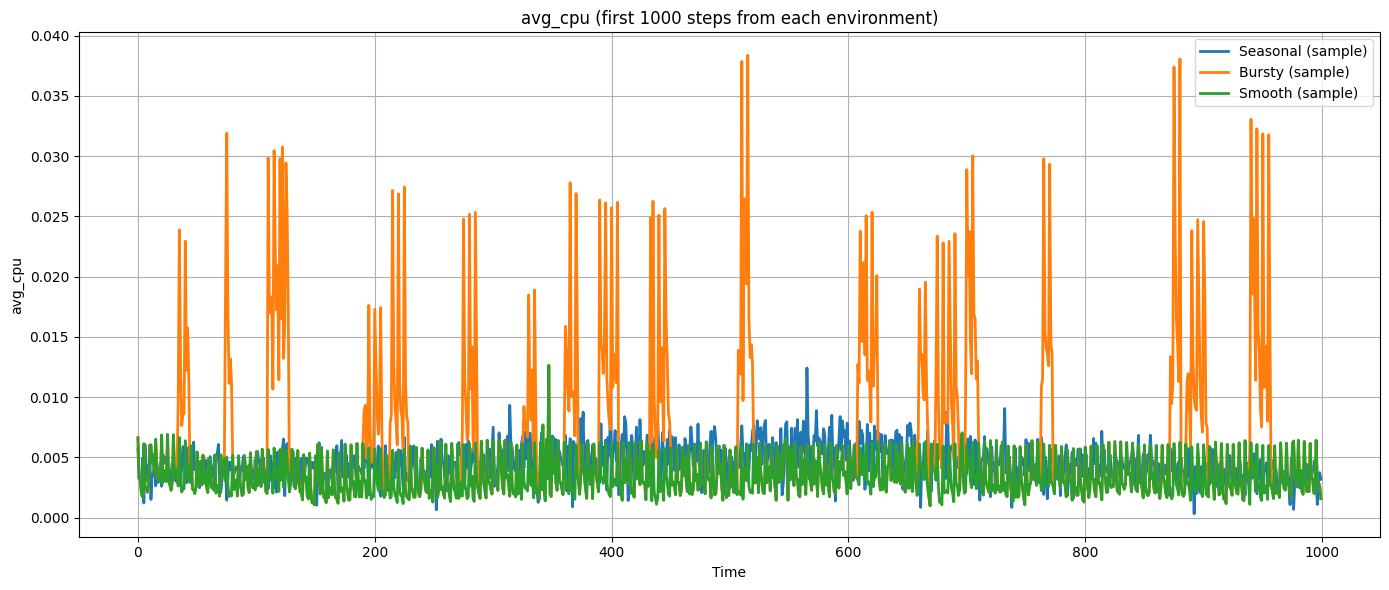

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

plt.plot(df_s_seasonal["avg_cpu"], label="Seasonal (sample)", linewidth=2)
plt.plot(df_s_bursty["avg_cpu"],   label="Bursty (sample)", linewidth=2)
plt.plot(df_s_smooth["avg_cpu"],   label="Smooth (sample)", linewidth=2)

plt.title(f"avg_cpu (first {N} steps from each environment)")
plt.xlabel("Time")
plt.ylabel("avg_cpu")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Recreate agents and load weights

In [ ]:
# Create a temporary environment to extract shapes
temp_env = AutoScalingEnv(df_smooth)   # or df_seasonal, df_bursty — doesn't matter

obs_shape = temp_env.observation_space.shape[0]   # e.g., 2 for [avg_cpu, capacity]
n_actions = temp_env.action_space.n               # e.g., 3 (down, hold, up)

print("obs_shape:", obs_shape)
print("n_actions:", n_actions)


obs_shape: 2
n_actions: 3


In [ ]:
from DQN_Agent import DQNAgent
from Double_DQN_Agent import DoubleDQNAgent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 1. Vanilla DQN
agent_dqn = DQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_dqn.qnetwork_local.load_state_dict(
    torch.load(DQN_CHECKPOINT_PATH, map_location=device)
)
agent_dqn.qnetwork_target.load_state_dict(agent_dqn.qnetwork_local.state_dict())
agent_dqn.qnetwork_local.to(device).eval()

# 2. Double DQN (standard network)
agent_double = DoubleDQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_double.qnetwork_local.load_state_dict(
    torch.load(DOUBLE_DQN_CHECKPOINT_PATH, map_location=device)
)
agent_double.qnetwork_target.load_state_dict(agent_double.qnetwork_local.state_dict())
agent_double.qnetwork_local.to(device).eval()

# 3. "Dueling Double DQN" – SAME CLASS, different trained weights
agent_dueling = DoubleDQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_dueling.qnetwork_local.load_state_dict(
    torch.load(DUELING_DQN_CHECKPOINT_PATH, map_location=device)
)
agent_dueling.qnetwork_target.load_state_dict(agent_dueling.qnetwork_local.state_dict())
agent_dueling.qnetwork_local.to(device).eval()

print("Loaded: DQN, Double DQN, and Dueling Double DQN (via DoubleDQNAgent).")


Using device: cpu
Loaded: DQN, Double DQN, and Dueling Double DQN (via DoubleDQNAgent).


#Evaluate All Models Against Three Environments

#Summary of Results

In [ ]:
import pandas as pd

data = [
    # Environment, Agent, MeanScore
    ("Seasonal", "DQN",               -3743.63),
    ("Seasonal", "DoubleDQN",         -3617.40),
    ("Seasonal", "DuelingDoubleDQN",  -2958.07),

    ("Bursty",   "DQN",               -15214.43),
    ("Bursty",   "DoubleDQN",         -17600.77),
    ("Bursty",   "DuelingDoubleDQN",  -25356.05),

    ("Smooth",   "DQN",               -4297.70),
    ("Smooth",   "DoubleDQN",         -3572.34),
    ("Smooth",   "DuelingDoubleDQN",  -2946.43),
]

df_results = pd.DataFrame(data, columns=["Environment", "Agent", "MeanScore"])
df_results


,Environment,Agent,MeanScore
0,Seasonal,DQN,-3743.63
1,Seasonal,DoubleDQN,-3617.40
2,Seasonal,DuelingDoubleDQN,-2958.07
3,Bursty,DQN,-15214.43
4,Bursty,DoubleDQN,-17600.77
5,Bursty,DuelingDoubleDQN,-25356.05
6,Smooth,DQN,-4297.70
7,Smooth,DoubleDQN,-3572.34
8,Smooth,DuelingDoubleDQN,-2946.43


In [ ]:
pivot = df_results.pivot(index="Environment", columns="Agent", values="MeanScore")
pivot


Agent,DQN,DoubleDQN,DuelingDoubleDQN
Environment,,,
Bursty,-15214.43,-17600.77,-25356.05
Seasonal,-3743.63,-3617.40,-2958.07
Smooth,-4297.70,-3572.34,-2946.43


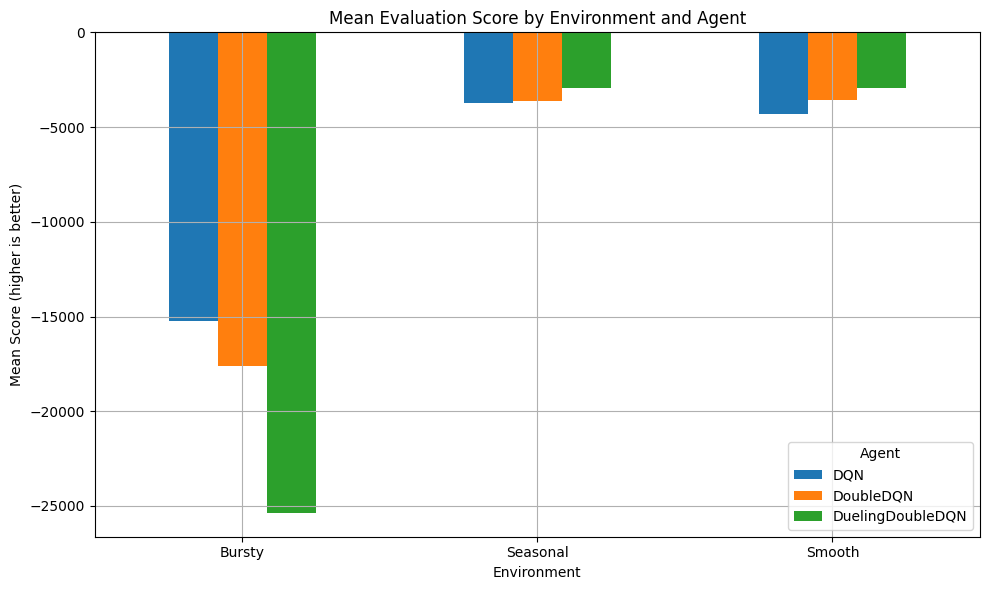

In [ ]:
import matplotlib.pyplot as plt

pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Mean Evaluation Score by Environment and Agent")
plt.ylabel("Mean Score (higher is better)")
plt.xlabel("Environment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


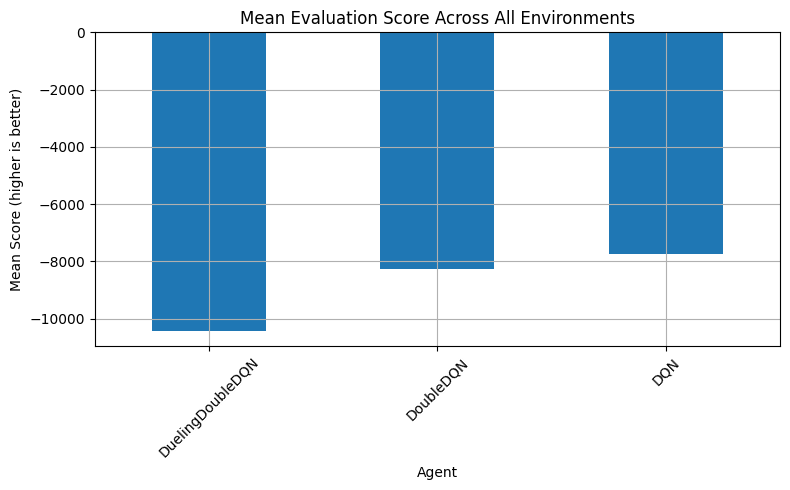

In [ ]:
agent_summary = df_results.groupby("Agent")["MeanScore"].mean().sort_values()

agent_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Mean Evaluation Score Across All Environments")
plt.ylabel("Mean Score (higher is better)")
plt.xlabel("Agent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


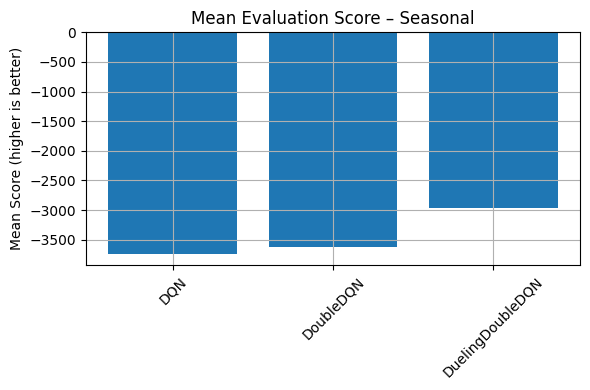

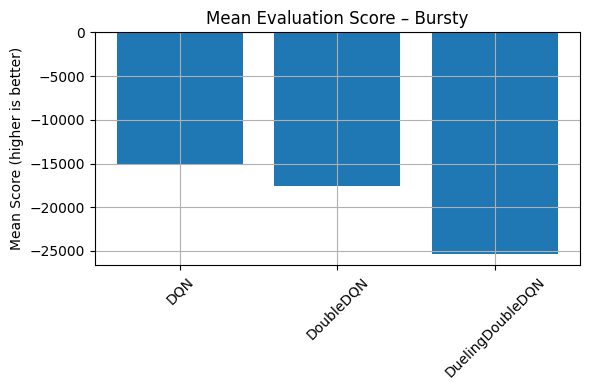

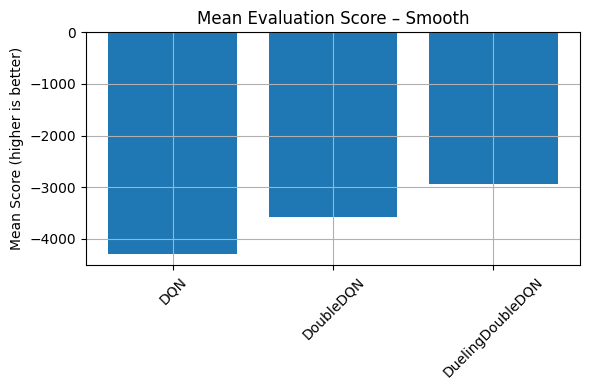

In [ ]:
envs = df_results["Environment"].unique()

for env in envs:
    subset = df_results[df_results["Environment"] == env]

    plt.figure(figsize=(6, 4))
    plt.bar(subset["Agent"], subset["MeanScore"])
    plt.title(f"Mean Evaluation Score – {env}")
    plt.ylabel("Mean Score (higher is better)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np

def run_episode_and_record(agent, env, max_steps=None):
    """
    Runs a single greedy (eps=0) evaluation episode on the environment
    and records step-by-step CPU, demand, capacity, utilization, reward.
    Returns a pandas DataFrame.
    """
    state, info = env.reset()
    done = False
    records = []

    step = 0
    while not done:
        action = agent.act(state, eps=0.0)
        next_state, reward, terminated, truncated, info_step = env.step(action)

        # Extract raw CPU from env state
        avg_cpu = state[0]
        capacity = state[1]

        demand = avg_cpu * env.config.demand_scale
        utilization = demand / capacity if capacity > 0 else 0

        records.append({
            "step": step,
            "avg_cpu": avg_cpu,
            "capacity": capacity,
            "demand": demand,
            "utilization": utilization,
            "reward": reward,
            "action": action,
        })

        state = next_state
        step += 1
        done = terminated or truncated or (max_steps and step >= max_steps)

    return pd.DataFrame(records)


In [ ]:
traj_seasonal_dqn = run_episode_and_record(agent_dqn, env_seasonal)
traj_seasonal_dqn.head()


,step,avg_cpu,capacity,demand,utilization,reward,action
0,0,0.005690,10.0,5.689886,0.568989,-0.104738,2
1,1,0.003208,11.0,3.208429,0.291675,-0.330325,2
2,2,0.003296,11.0,3.296104,0.299646,-0.322354,2
3,3,0.002655,11.0,2.654593,0.241327,-0.380673,2
4,4,0.004944,11.0,4.943753,0.449432,-0.125625,0


In [ ]:
traj_bursty_double = run_episode_and_record(agent_double, env_bursty)
traj_smooth_dueling = run_episode_and_record(agent_dueling, env_smooth)


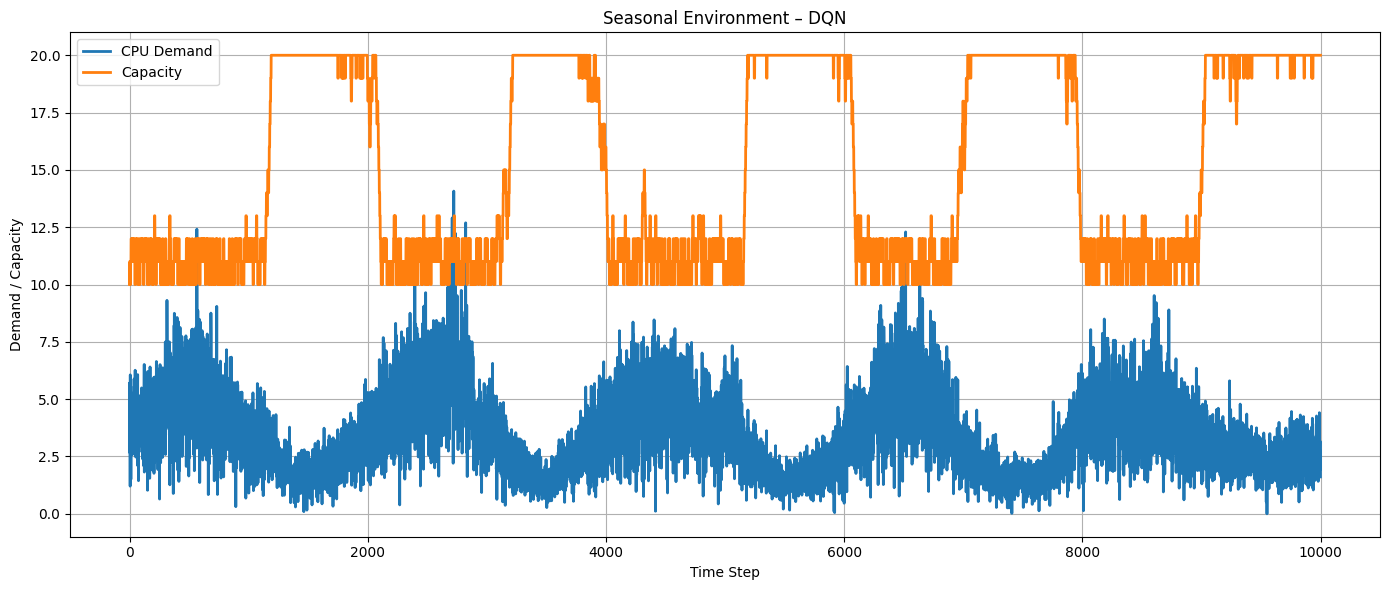

In [ ]:
import matplotlib.pyplot as plt

def plot_capacity_vs_demand(traj, title):
    plt.figure(figsize=(14, 6))

    plt.plot(traj["step"], traj["demand"], label="CPU Demand", linewidth=2)
    plt.plot(traj["step"], traj["capacity"], label="Capacity", linewidth=2)

    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Demand / Capacity")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_capacity_vs_demand(traj_seasonal_dqn, "Seasonal Environment – DQN")


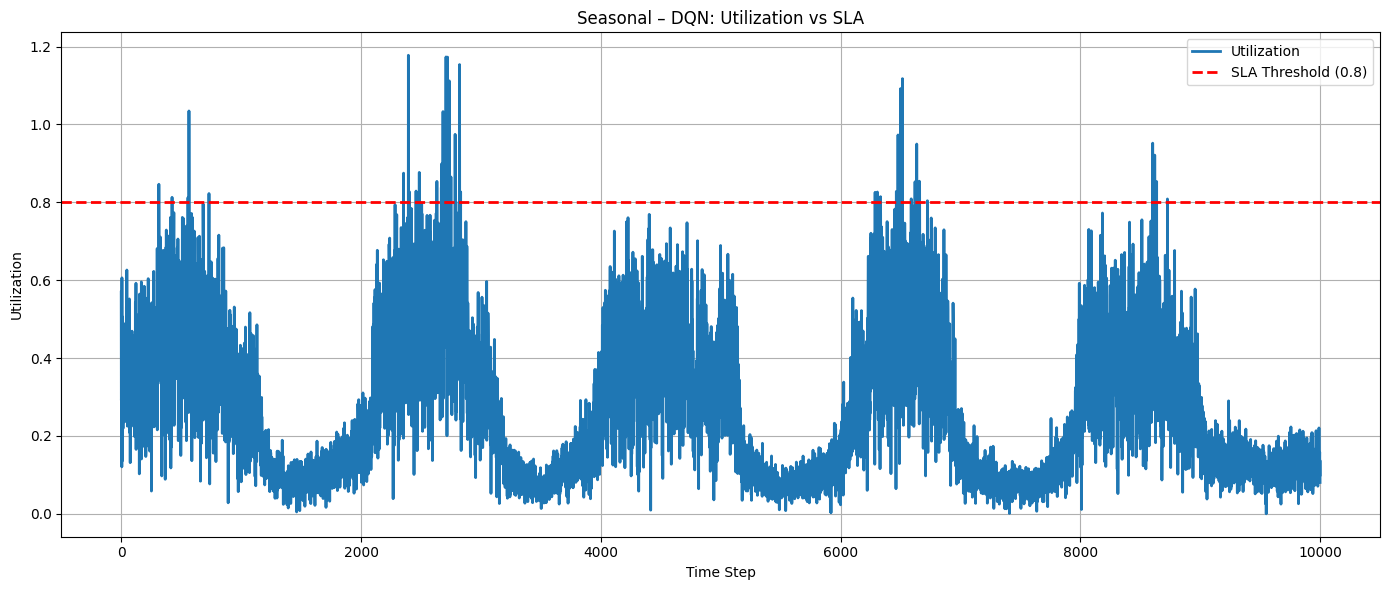

In [ ]:
def plot_utilization_vs_sla(traj, env, title):
    plt.figure(figsize=(14, 6))

    plt.plot(traj["step"], traj["utilization"], label="Utilization", linewidth=2)
    plt.axhline(env.config.sla_threshold, color="red", linestyle="--", linewidth=2,
                label=f"SLA Threshold ({env.config.sla_threshold})")

    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Utilization")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example:
plot_utilization_vs_sla(traj_seasonal_dqn, env_seasonal,
                        "Seasonal – DQN: Utilization vs SLA")


In [ ]:
envs = {
    "Seasonal": env_seasonal,
    "Bursty":   env_bursty,
    "Smooth":   env_smooth,
}

agents = {
    "DQN":              agent_dqn,
    "DoubleDQN":        agent_double,
    "DuelingDoubleDQN": agent_dueling,
}


In [ ]:
trajectories = {}

max_steps_eval = 1000  # or None to run full length; 1000 keeps plots readable

for env_name, env in envs.items():
    for agent_name, agent in agents.items():
        key = (env_name, agent_name)
        print(f"Running {agent_name} on {env_name} ...")
        traj = run_episode_and_record(agent, env, max_steps=max_steps_eval)
        trajectories[key] = traj


Running DQN on Seasonal ...
Running DoubleDQN on Seasonal ...
Running DuelingDoubleDQN on Seasonal ...
Running DQN on Bursty ...
Running DoubleDQN on Bursty ...
Running DuelingDoubleDQN on Bursty ...
Running DQN on Smooth ...
Running DoubleDQN on Smooth ...
Running DuelingDoubleDQN on Smooth ...


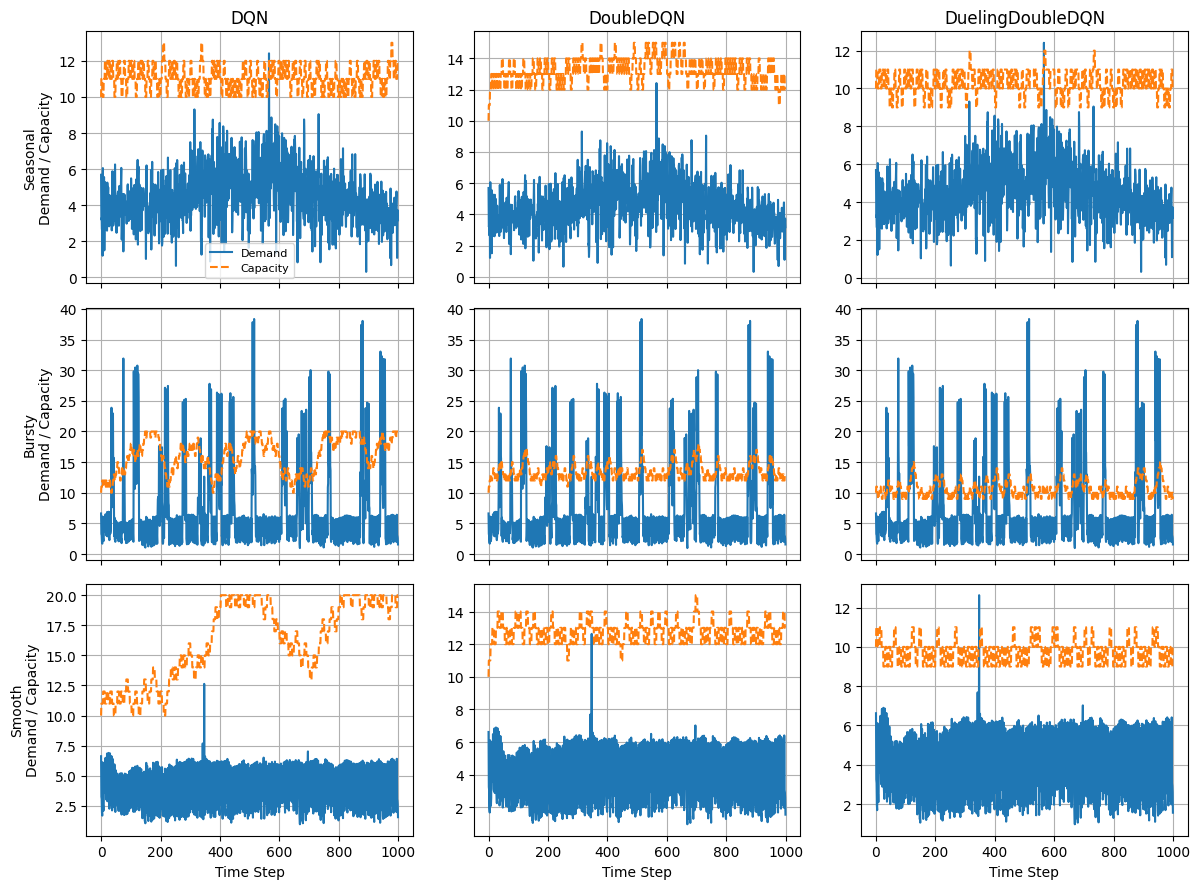

In [ ]:
import matplotlib.pyplot as plt

env_names = list(envs.keys())          # ["Seasonal", "Bursty", "Smooth"]
agent_names = list(agents.keys())      # ["DQN", "DoubleDQN", "DuelingDoubleDQN"]

n_envs = len(env_names)
n_agents = len(agent_names)

fig, axes = plt.subplots(
    n_envs,
    n_agents,
    figsize=(4 * n_agents, 3 * n_envs),
    sharex=True,
    sharey=False,
)

for i, env_name in enumerate(env_names):
    for j, agent_name in enumerate(agent_names):
        ax = axes[i, j] if n_envs > 1 else axes[j]
        traj = trajectories[(env_name, agent_name)]

        ax.plot(traj["step"], traj["demand"], linewidth=1.5, label="Demand")
        ax.plot(traj["step"], traj["capacity"], linewidth=1.5, linestyle="--", label="Capacity")

        if i == 0:
            ax.set_title(agent_name)
        if j == 0:
            ax.set_ylabel(f"{env_name}\nDemand / Capacity")
        if i == n_envs - 1:
            ax.set_xlabel("Time Step")

        if i == 0 and j == 0:
            ax.legend(fontsize=8)

        ax.grid(True)

plt.tight_layout()
plt.show()


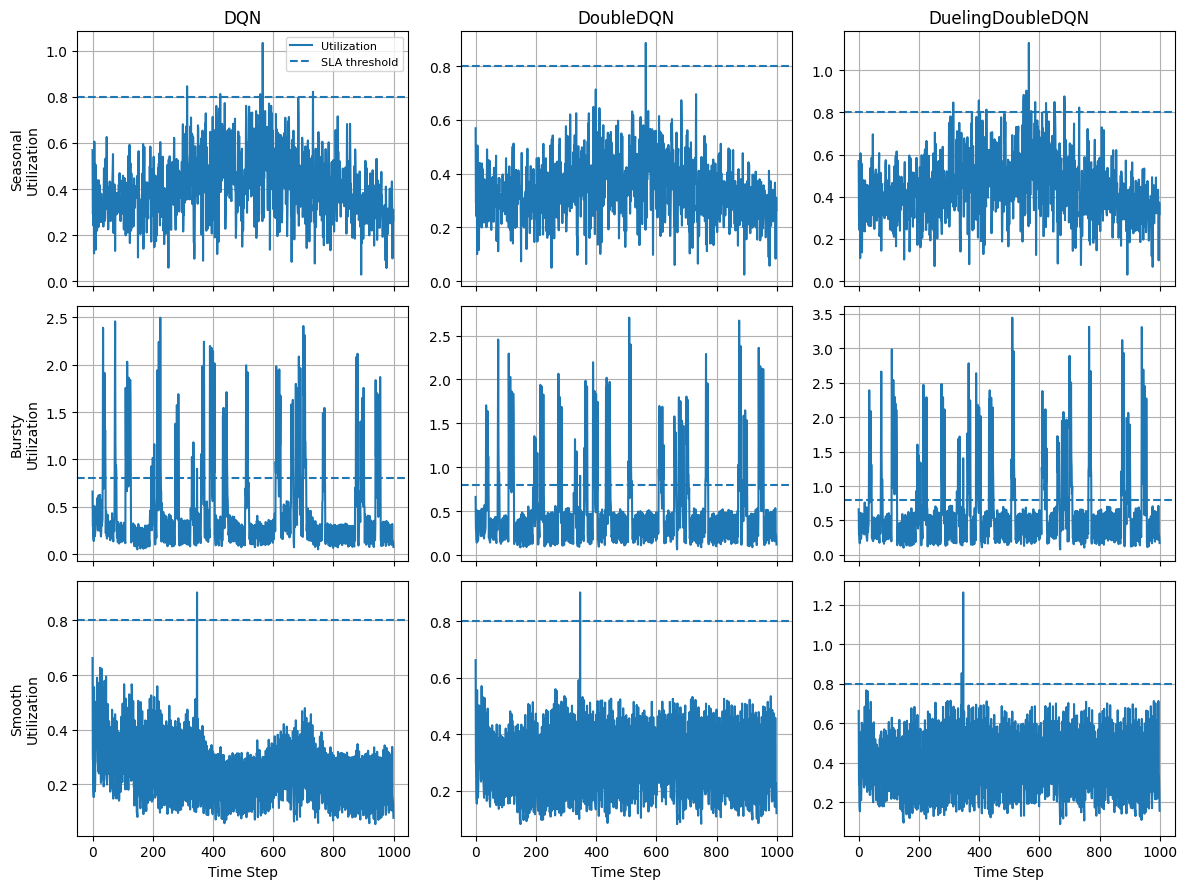

In [ ]:
fig, axes = plt.subplots(
    n_envs,
    n_agents,
    figsize=(4 * n_agents, 3 * n_envs),
    sharex=True,
    sharey=False,
)

for i, env_name in enumerate(env_names):
    for j, agent_name in enumerate(agent_names):
        ax = axes[i, j] if n_envs > 1 else axes[j]
        traj = trajectories[(env_name, agent_name)]
        env = envs[env_name]

        ax.plot(traj["step"], traj["utilization"], linewidth=1.5, label="Utilization")
        ax.axhline(env.config.sla_threshold, linestyle="--", linewidth=1.5,
                   label="SLA threshold")

        if i == 0:
            ax.set_title(agent_name)
        if j == 0:
            ax.set_ylabel(f"{env_name}\nUtilization")
        if i == n_envs - 1:
            ax.set_xlabel("Time Step")

        if i == 0 and j == 0:
            ax.legend(fontsize=8)

        ax.grid(True)

plt.tight_layout()
plt.show()


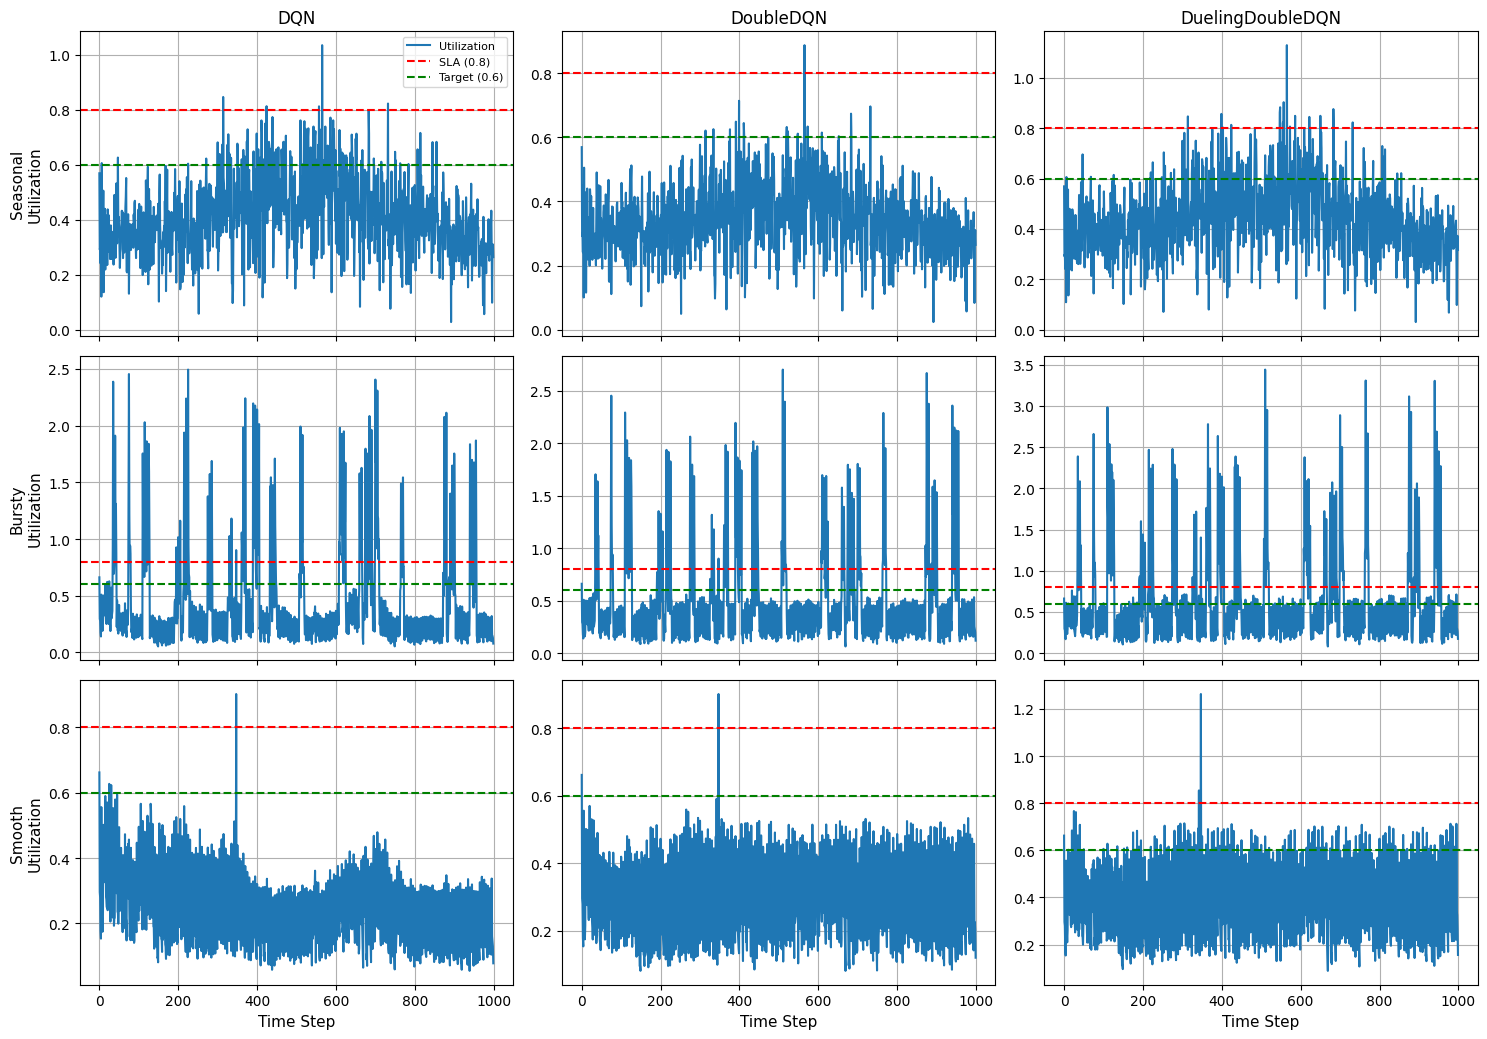

In [ ]:
import matplotlib.pyplot as plt

env_names = list(envs.keys())          # ["Seasonal", "Bursty", "Smooth"]
agent_names = list(agents.keys())      # ["DQN", "DoubleDQN", "DuelingDoubleDQN"]

n_envs = len(env_names)
n_agents = len(agent_names)

fig, axes = plt.subplots(
    n_envs,
    n_agents,
    figsize=(5 * n_agents, 3.5 * n_envs),
    sharex=True,
    sharey=False,
)

for i, env_name in enumerate(env_names):
    for j, agent_name in enumerate(agent_names):
        ax = axes[i, j]
        traj = trajectories[(env_name, agent_name)]
        env = envs[env_name]

        # Plot utilization
        ax.plot(
            traj["step"], traj["utilization"],
            linewidth=1.5, label="Utilization"
        )

        # SLA threshold
        ax.axhline(
            env.config.sla_threshold,
            linestyle="--", color="red", linewidth=1.5,
            label=f"SLA ({env.config.sla_threshold})"
        )

        # Target utilization
        ax.axhline(
            env.config.target_utilization,
            linestyle="--", color="green", linewidth=1.5,
            label=f"Target ({env.config.target_utilization})"
        )

        # Titles/labels
        if i == 0:
            ax.set_title(agent_name, fontsize=12)

        if j == 0:
            ax.set_ylabel(f"{env_name}\nUtilization", fontsize=11)

        if i == n_envs - 1:
            ax.set_xlabel("Time Step", fontsize=11)

        # Legend only on top-left plot
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

        ax.grid(True)

plt.tight_layout()
plt.show()


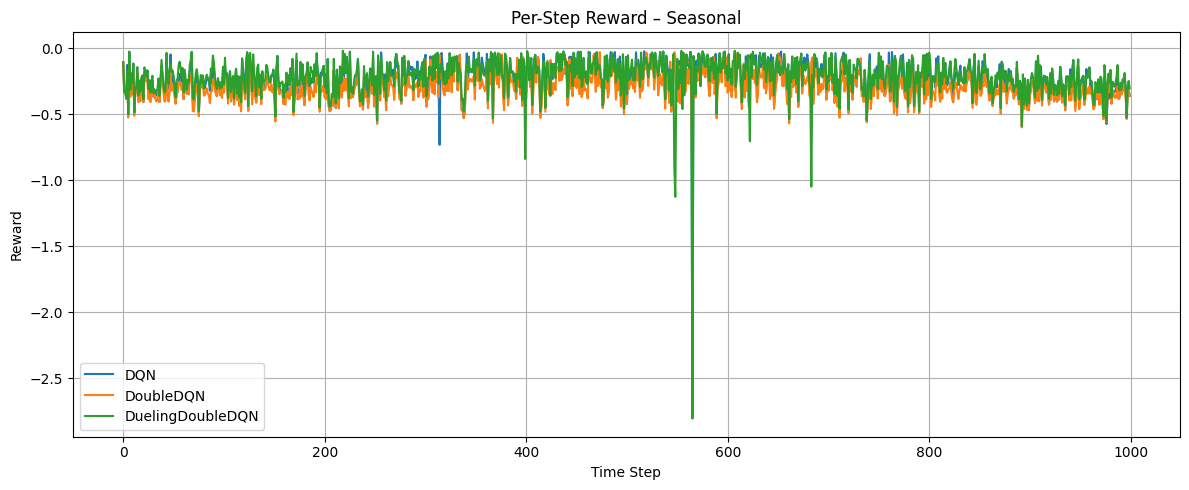

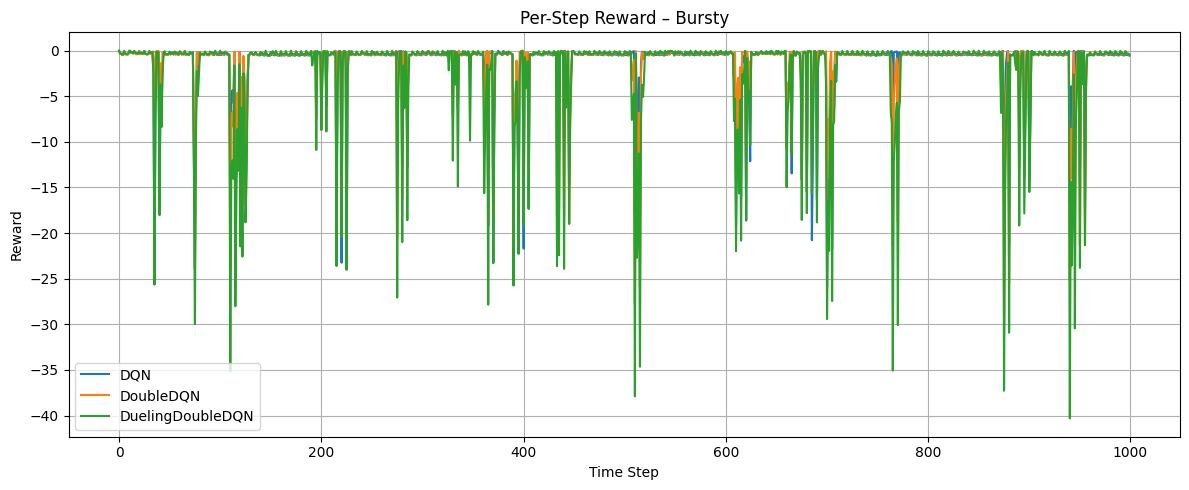

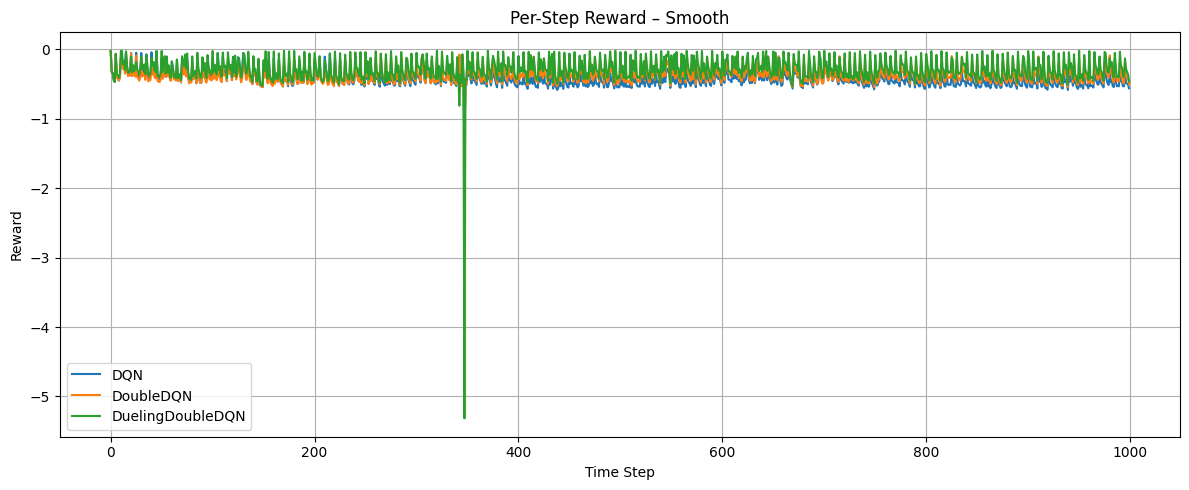

In [ ]:
import matplotlib.pyplot as plt

def plot_reward_overlay_for_env(env_name, trajectories, agent_names=None, max_steps=None):
    """
    For a single environment, overlay per-step reward trajectories
    for all agents on one plot.
    """
    if agent_names is None:
        # infer from keys
        agent_names = sorted({a for (e, a) in trajectories.keys() if e == env_name})

    plt.figure(figsize=(12, 5))

    for agent_name in agent_names:
        traj = trajectories[(env_name, agent_name)]
        if max_steps is not None:
            traj = traj.iloc[:max_steps]

        plt.plot(traj["step"], traj["reward"], label=agent_name)

    plt.title(f"Per-Step Reward – {env_name}")
    plt.xlabel("Time Step")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example calls:
plot_reward_overlay_for_env("Seasonal", trajectories)
plot_reward_overlay_for_env("Bursty", trajectories)
plot_reward_overlay_for_env("Smooth", trajectories)


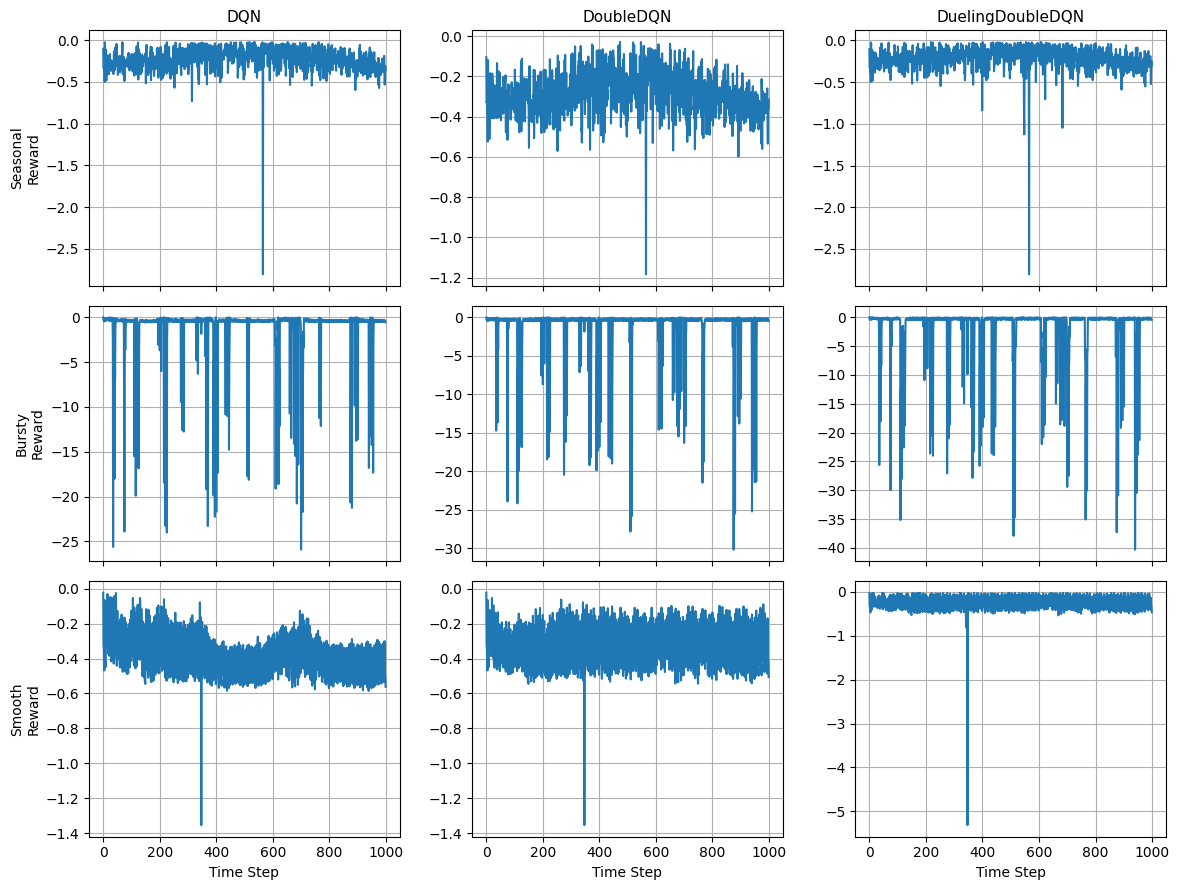

In [ ]:
env_names = list(envs.keys())          # ["Seasonal", "Bursty", "Smooth"]
agent_names = list(agents.keys())      # ["DQN", "DoubleDQN", "DuelingDoubleDQN"]

n_envs = len(env_names)
n_agents = len(agent_names)

max_steps_plot = 1000  # None for full length, or trim for readability

fig, axes = plt.subplots(
    n_envs,
    n_agents,
    figsize=(4 * n_agents, 3 * n_envs),
    sharex=True,
    sharey=False,
)

for i, env_name in enumerate(env_names):
    for j, agent_name in enumerate(agent_names):
        ax = axes[i, j]
        traj = trajectories[(env_name, agent_name)]

        if max_steps_plot is not None:
            traj = traj.iloc[:max_steps_plot]

        ax.plot(traj["step"], traj["reward"])

        if i == 0:
            ax.set_title(agent_name, fontsize=11)

        if j == 0:
            ax.set_ylabel(f"{env_name}\nReward", fontsize=10)

        if i == n_envs - 1:
            ax.set_xlabel("Time Step", fontsize=10)

        ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

sla_results = []

for env_name, env in envs.items():
    sla_thr = env.config.sla_threshold
    for agent_name, agent in agents.items():
        traj = trajectories[(env_name, agent_name)]

        # Count violations
        violations = (traj["utilization"] > sla_thr).sum()

        # Store
        sla_results.append({
            "Environment": env_name,
            "Agent": agent_name,
            "SLA_Threshold": sla_thr,
            "Violations": violations,
            "Total_Steps": len(traj),
            "Violation_Rate": violations / len(traj)
        })

df_sla = pd.DataFrame(sla_results)
df_sla


,Environment,Agent,SLA_Threshold,Violations,Total_Steps,Violation_Rate
0,Seasonal,DQN,0.8,5,1000,0.005
1,Seasonal,DoubleDQN,0.8,1,1000,0.001
2,Seasonal,DuelingDoubleDQN,0.8,15,1000,0.015
3,Bursty,DQN,0.8,136,1000,0.136
4,Bursty,DoubleDQN,0.8,143,1000,0.143
5,Bursty,DuelingDoubleDQN,0.8,189,1000,0.189
6,Smooth,DQN,0.8,1,1000,0.001
7,Smooth,DoubleDQN,0.8,1,1000,0.001
8,Smooth,DuelingDoubleDQN,0.8,2,1000,0.002


In [ ]:
df_sla_matrix = df_sla.pivot(index="Environment", columns="Agent", values="Violations")
df_sla_matrix


Agent,DQN,DoubleDQN,DuelingDoubleDQN
Environment,,,
Bursty,136,143,189
Seasonal,5,1,15
Smooth,1,1,2


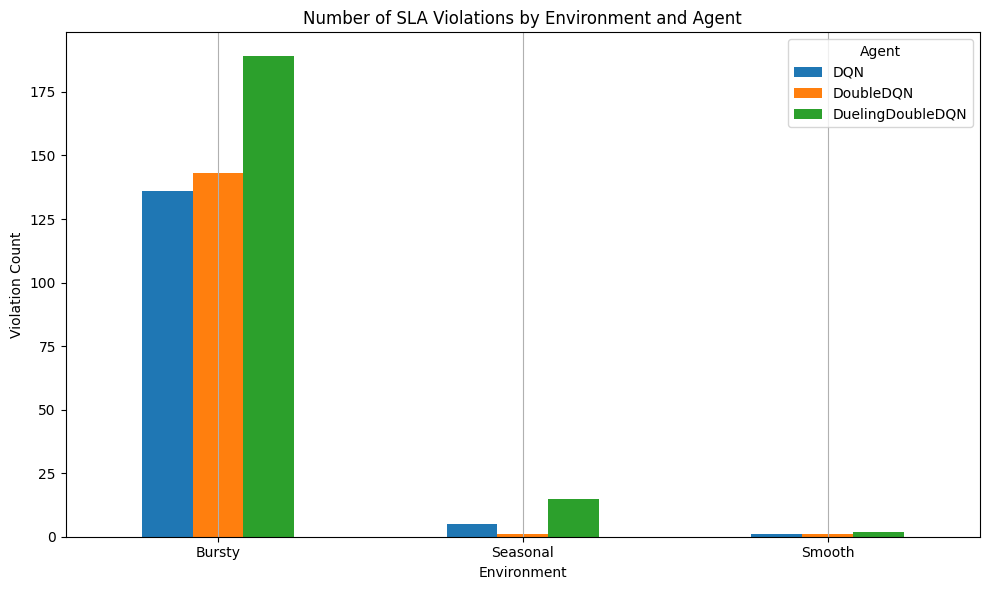

In [ ]:
import matplotlib.pyplot as plt

df_sla_matrix.plot(kind="bar", figsize=(10, 6))

plt.title("Number of SLA Violations by Environment and Agent")
plt.ylabel("Violation Count")
plt.xlabel("Environment")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
